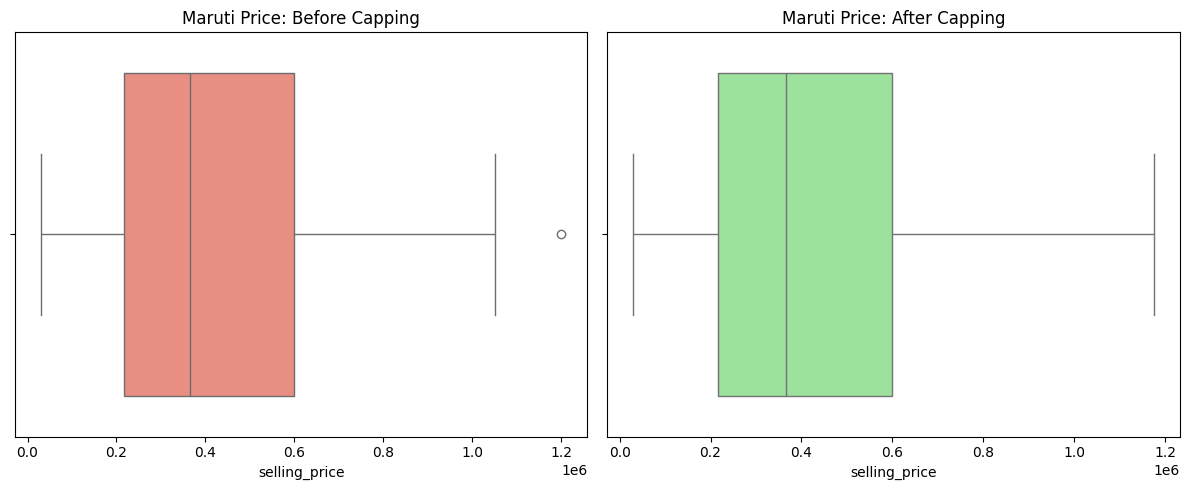

In [29]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('Car details v3.csv')
df.columns = df.columns.str.lower()

df['mileage'] = df['mileage'].str.split(' ').str[0].astype(float)
df['engine'] = df['engine'].str.split(' ').str[0].astype(float)
df['max_power'] = df['max_power'].str.split(' ').str[0]
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')


df['mileage'] = df['mileage'].fillna(df['mileage'].median())
df['engine'] = df['engine'].fillna(df['engine'].median())
df['max_power'] = df['max_power'].fillna(df['max_power'].median())
df['seats'] = df['seats'].fillna(df['seats'].median())


df['brand'] = df['name'].str.split(' ').str[0]


def cap_outliers(group):
    q1 = group['selling_price'].quantile(0.25)
    q3 = group['selling_price'].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    group['selling_price'] = np.clip(group['selling_price'], lower_limit, upper_limit)
    return group


df_cleaned = df.groupby('brand', group_keys=False).apply(cap_outliers)

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
sns.boxplot(x='selling_price', data=df[df['brand'] == 'Maruti'], color='salmon')
plt.title('Maruti Price: Before Capping')


plt.subplot(1, 2, 2)
sns.boxplot(x='selling_price', data=df_cleaned[df_cleaned['brand'] == 'Maruti'], color='lightgreen')
plt.title('Maruti Price: After Capping')

plt.tight_layout()
plt.show()

In [32]:
df_cleaned['car_age']=2026-df_cleaned['year']
df_cleaned['km_per_year']=df_cleaned['km_driven']/df_cleaned['car_age'].replace(0,1)
df_cleaned['price_per_seat']=df_cleaned['selling_price']/df_cleaned['seats']
selected_table_cols=['name','year','car_age','km_driven','km_per_year','selling_price','price_per_seat']
df_cleaned[selected_table_cols].head()

,name,year,car_age,km_driven,km_per_year,selling_price,price_per_seat
0,Maruti Swift Dzire VDI,2014,12,145500,12125.000000,450000.0,90000.0
1,Skoda Rapid 1.5 TDI Ambition,2014,12,120000,10000.000000,370000.0,74000.0
2,Honda City 2017-2020 EXi,2006,20,140000,7000.000000,158000.0,31600.0
3,Hyundai i20 Sportz Diesel,2010,16,127000,7937.500000,225000.0,45000.0
4,Maruti Swift VXI BSIII,2007,19,120000,6315.789474,130000.0,26000.0


In [34]:


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error


categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']
df_final = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

X = df_final.drop(columns=['selling_price', 'name', 'brand', 'torque'])
y = df_final['selling_price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("============ 🎯 ML MODEL REPORT ============")
print(f"🎉 Model Successfully Train Ho Gaya!")
print(f"📈 Accuracy (R2 Score): {r2 * 100:.2f}%")
print(f"💸 Average Price Error (MAE): ₹{mae:.2f}")
print("============================================")

============ 🎯 ML MODEL REPORT ============
🎉 Model Successfully Train Ho Gaya!
📈 Accuracy (R2 Score): 98.99%
💸 Average Price Error (MAE): ₹31320.49


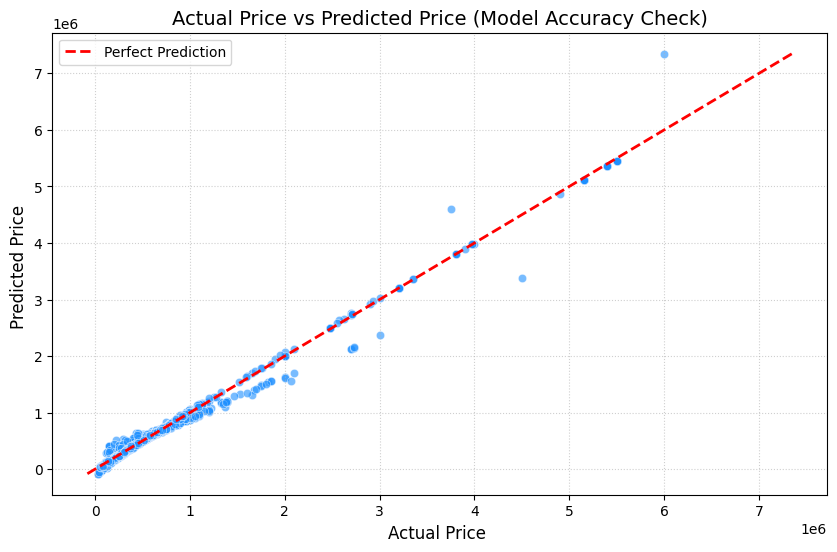


📊  Car Predictions  (Table):


,Actual Price,Predicted Price
0,198000.0,188518.745080
1,500000.0,559771.612607
2,425000.0,431775.469800
3,150000.0,138974.310191
4,525000.0,518102.300081
5,160000.0,142888.503955
6,450000.0,509979.120987
7,570000.0,579482.881280
8,170000.0,149888.019551
9,135000.0,117167.464944


In [37]:

comparison_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
}).reset_index(drop=True)


plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual Price', y='Predicted Price', data=comparison_df, color='dodgerblue', alpha=0.6)


max_val = max(comparison_df['Actual Price'].max(), comparison_df['Predicted Price'].max())
min_val = min(comparison_df['Actual Price'].min(), comparison_df['Predicted Price'].min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Actual Price vs Predicted Price (Model Accuracy Check)', fontsize=14)
plt.xlabel('Actual Price ', fontsize=12)
plt.ylabel('Predicted Price ', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


print("\n📊  Car Predictions  (Table):")
comparison_df.head(10)